In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation, percentileofscore

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
NOTARAS_SRR_FOLDERS = glob.glob('/mnt/sdb/scz_meta_analysis_processed/notaras_colak/star_outputs/*_Solo.out/')

In [3]:
Y_CHR_GENES = [
    "SRY",       # sex determining region Y :contentReference[oaicite:1]{index=1}
    "ZFY",       # zinc finger protein, Y‑linked :contentReference[oaicite:2]{index=2}
    "RPS4Y1",    # ribosomal protein S4, Y‑linked 1 :contentReference[oaicite:3]{index=3}
    "AMELY",     # amelogenin, Y‑linked :contentReference[oaicite:4]{index=4}
    "TSPY1",     # testis specific protein, Y‑encoded 1 :contentReference[oaicite:5]{index=5}
    "BPY2",      # basic charge Y‑linked 2 :contentReference[oaicite:6]{index=6}
    "UTY",       # ubiquitously transcribed tetratricopeptide repeat, Y‑linked :contentReference[oaicite:7]{index=7}
    "DDX3Y",     # DEAD‑box helicase 3, Y‑linked :contentReference[oaicite:8]{index=8}
    "USP9Y",     # ubiquitin specific peptidase 9 Y‑linked :contentReference[oaicite:9]{index=9}
    "RBMY1A1",   # RNA binding motif protein Y, family 1 A1 :contentReference[oaicite:10]{index=10}
    "CDY1",      # chromodomain protein Y‑linked 1 :contentReference[oaicite:11]{index=11}
    "CDY2A",     # chromodomain protein Y‑linked 2A :contentReference[oaicite:12]{index=12}
    "EIF1AY",    # eukaryotic translation initiation factor 1A Y‑linked :contentReference[oaicite:13]{index=13}
    # Pseudoautosomal region genes (present on both X and Y):
    "PAR1_PLCXD1",   # phosphatidylinositol specific phospholipase C X domain containing 1 (PAR1) :contentReference[oaicite:14]{index=14}
    "PAR1_GTPBP6",   # GTP binding protein 6 (PAR1) :contentReference[oaicite:15]{index=15}
    # Miscellaneous/other Y‑linked loci:
    "XGY1",      # XG Y‑linked 1 (pseudogene) :contentReference[oaicite:16]{index=16}
    # Additional annotated or reported Y‑linked genes:
    "VCY",       # variable charge Y‑linked (gene family) :contentReference[oaicite:17]{index=17}
    "PCDH11Y",   # protocadherin 11 Y‑linked :contentReference[oaicite:18]{index=18}
    "TGIF2LY",   # TGFB induced factor homeobox 2 like, Y‑linked :contentReference[oaicite:19]{index=19}
    "OFD1P1Y",   # OFD1 pseudogene 1 Y‑linked :contentReference[oaicite:20]{index=20}
]

In [4]:
## From Cellbender Import ##

notaras_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/notaras_colak/anndata_objs/notaras_cellbendered.h5ad')

notaras_adata.obs['Run'] = [i.split('_')[0] for i in notaras_adata.obs_names]

notaras_adata.obs['barcodes'] = notaras_adata.obs_names

# filter ambient rna
notaras_adata = notaras_adata[notaras_adata.obs['cell']].copy()

In [5]:
## Cells After Ambient RNA Removal ##

notaras_adata.shape

(222930, 33538)

In [6]:
## Merge SRA Metadata ##

notaras_sra_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/metadata/Notaras_SRA_RunTable.csv')

notaras_sra_metadata_essential = notaras_sra_metadata[['Run', 'BioProject', 'BioSample', 'disease_state', 
                                                       'Donor', 'Experiment', 'GEO_Accession (exp)', 'Instrument',
                                                       'ReleaseDate', 'create_date','Sample Name', 'source_name', 'SRA Study']]

notaras_adata.obs = notaras_adata.obs.merge(notaras_sra_metadata_essential, left_on='Run', right_on='Run', how='left')

notaras_adata.obs.index = notaras_adata.obs['barcodes']

notaras_adata.obs['Donor'] = notaras_adata.obs['Donor'].str.strip(';')

In [7]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
notaras_adata.var['ensembl_gene_id'] = notaras_adata.var.index
#del notaras_adata.var['gene_name']
notaras_adata.var = notaras_adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
notaras_adata.var.chromosome_name = notaras_adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
notaras_adata.var.loc[notaras_adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = notaras_adata.var.loc[notaras_adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
notaras_adata.var.index = notaras_adata.var['hgnc_symbol']
notaras_adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
notaras_adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_129636/3771626602.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


66195

In [8]:
## Donor Metadata From Supplementary Table 2 of Paper ##

notaras_donor_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/notaras_colak_molecular_psychiatry_2021/metadata/Notaras_Donor_Metadata.csv')

notaras_adata.obs = notaras_adata.obs.merge(notaras_donor_metadata, 
                                            left_on='Donor', 
                                            right_on='NIH iPSC Scz Line', how='left').set_index('barcodes')

notaras_adata.obs['Sex'] = notaras_adata.obs['Sex'].astype('str')

In [9]:
print(notaras_adata.obs.shape[0])
print(notaras_adata.obs['Sex'].value_counts())

## Note: Some of the Donor IDs don't have a Sex, because metadata isn't listed ##
# We will need to Impute Later ##

222930
Sex
nan     118738
Male    104192
Name: count, dtype: int64


In [10]:
## Remove Duplicate Barcodes ##

print(notaras_adata.obs_names.duplicated(keep=False).any())
print(notaras_adata.var_names.duplicated(keep=False).any())

# None

False
False


In [11]:
## Set Up QC Metrics ##

# filter on robust genes
pg.identify_robust_genes(notaras_adata, percent_cells=0.05)
notaras_adata = notaras_adata[:,notaras_adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
notaras_adata.var["mt"] = notaras_adata.var_names.str.startswith("MT-")
# ribosomal genes
notaras_adata.var["ribo"] = notaras_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
notaras_adata.var["hb"] = notaras_adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
notaras_adata.var['protein_coding'] = notaras_adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
notaras_adata.var['protein_coding'] = notaras_adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
notaras_adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in notaras_adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
notaras_adata.var['robust_protein_coding'] = notaras_adata.var['robust'] & notaras_adata.var['protein_coding']
notaras_adata.var.loc[notaras_adata.var.ribo, 'robust_protein_coding'] = False
notaras_adata.var.loc[notaras_adata.var.mt, 'robust_protein_coding'] = False
notaras_adata.var.loc[notaras_adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
notaras_adata.var['autosome'] = notaras_adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
notaras_adata.var['robust_protein_coding_autosome'] = notaras_adata.var['robust_protein_coding'] & notaras_adata.var['autosome'] 

2026-02-23 16:33:49,147 - pegasus.tools.preprocessing - INFO - After filtration, 26346/33538 genes are kept. Among 26346 genes, 16776 genes are robust.
2026-02-23 16:33:49,147 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 0.96s.


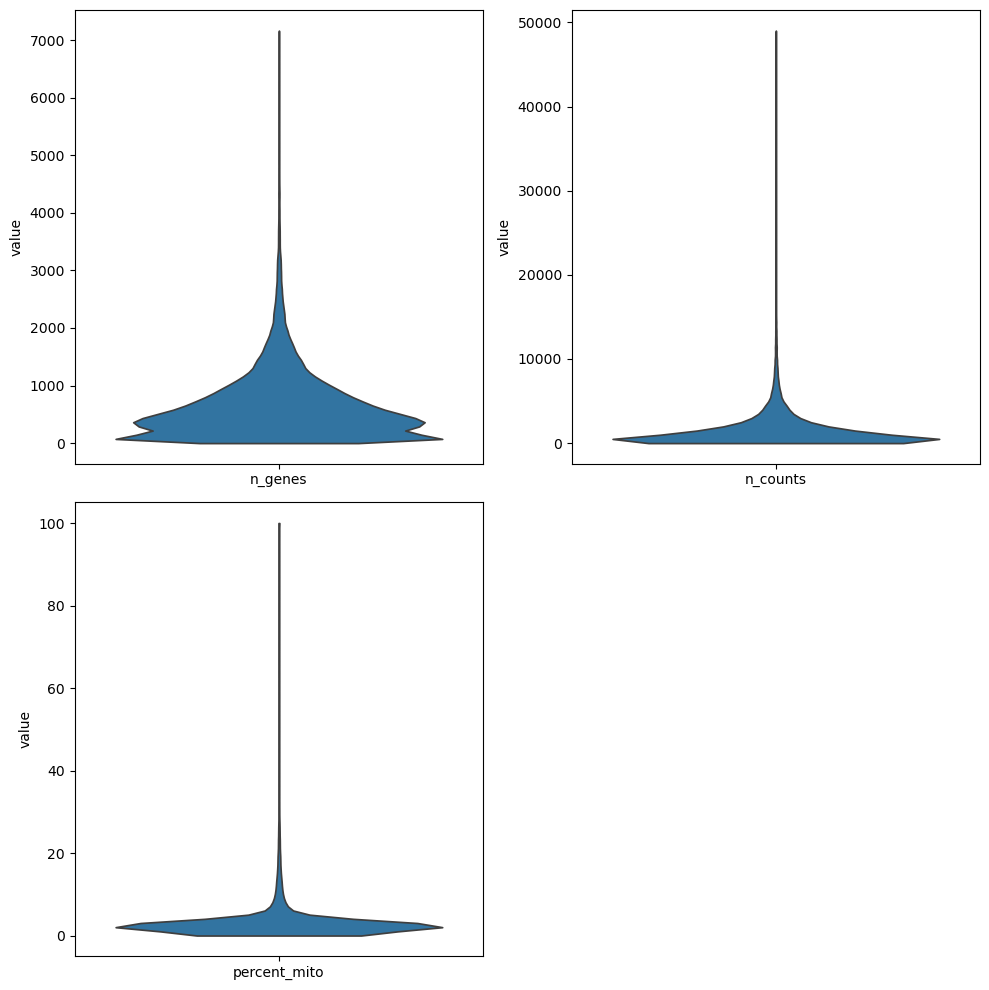

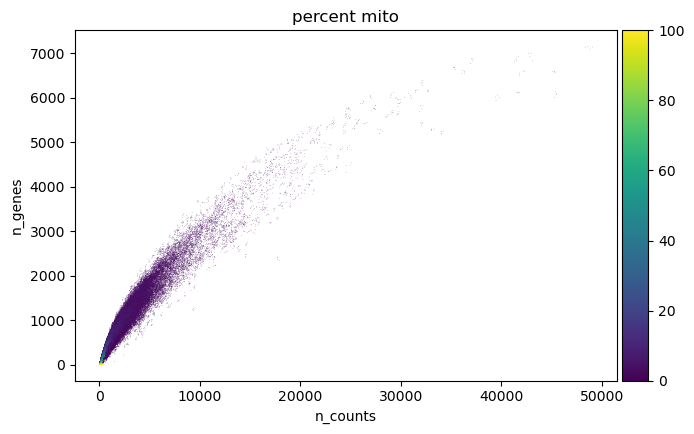

The 99th percentile all sample genes/cell is: 1818.0
The 99th percentile all sample total counts/cell is: 5299.0
The 99th percentile all sample mitochondrial % /cell is: 10.123191681735898


In [12]:
## Plot QC Metrics ##

# QC by counts #
# convert to pegasus unimodal object
notaras_adata = UnimodalData(notaras_adata)
pg.qc_metrics(notaras_adata, mito_prefix='MT-')

# Create a figure with 3 subplots

# convert back for plotting to scanpy anndata
notaras_adata = notaras_adata.to_anndata()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sc.pl.violin(notaras_adata, "n_genes", ax=axes[0], show=False, stripplot=False)
sc.pl.violin(notaras_adata, "n_counts", ax=axes[1], show=False, stripplot=False)
sc.pl.violin(notaras_adata, "percent_mito", ax=axes[2], show=False, stripplot=False)
fig.delaxes(axes[3])
plt.tight_layout()

sc.pl.scatter(notaras_adata, "n_counts", "n_genes", color="percent_mito")

print('The 99th percentile all sample genes/cell is: {0}'.format(np.percentile(notaras_adata.obs['n_genes'], 95)))

print('The 99th percentile all sample total counts/cell is: {0}'.format(np.percentile(notaras_adata.obs['n_counts'], 95)))

print('The 99th percentile all sample mitochondrial % /cell is: {0}'.format(np.percentile(notaras_adata.obs['percent_mito'], 95)))

n_UMIs lower: 80 upper: 10799
n_genes lower: 73 upper: 3222


/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


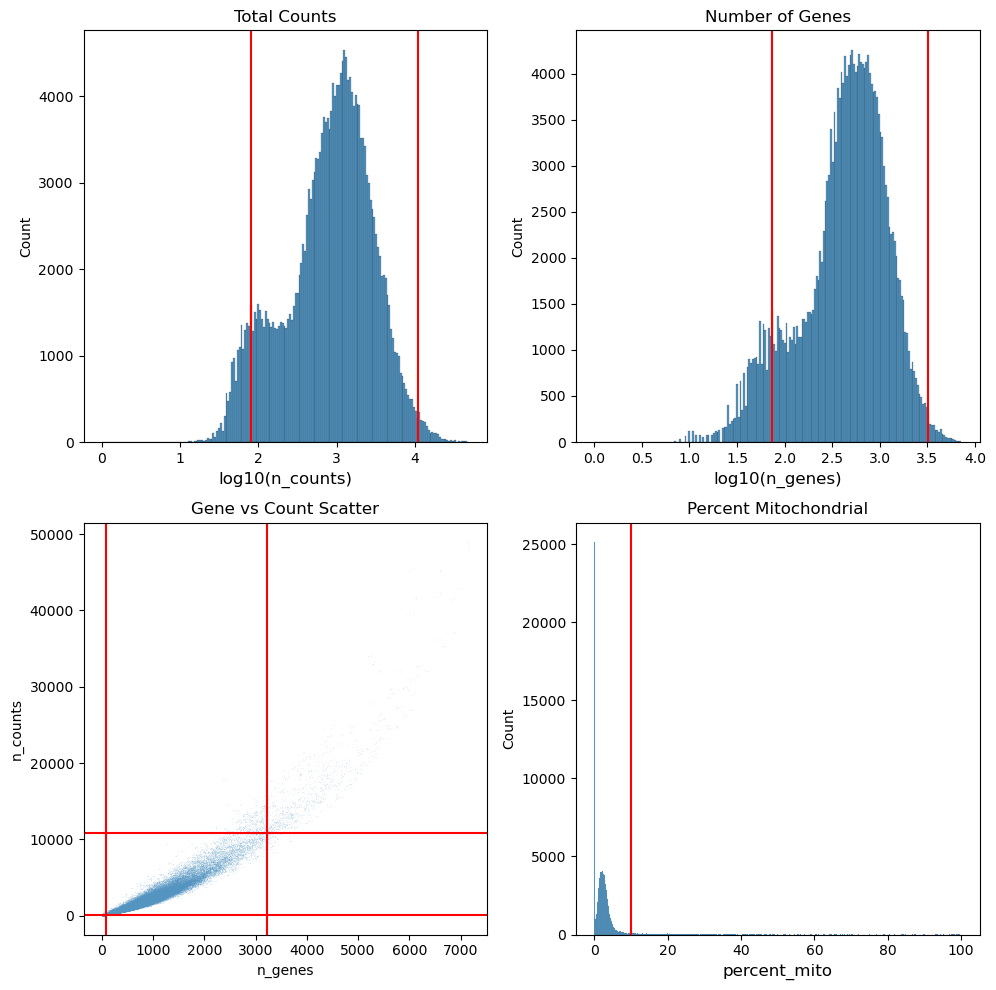

In [13]:
## Visualizating QC Cutoffs ##

MAD = 3

def qc_boundary(counts, k=MAD):
    x = np.log1p(counts)
    mad = median_abs_deviation(x)
    return np.exp(np.median(x) - k*mad), np.exp(np.median(x) + k*mad)

### nUMI and nGene QCs
n_counts_lower, n_counts_upper = qc_boundary(notaras_adata.obs.n_counts, k=MAD)
print('n_UMIs lower: %d upper: %d' % (n_counts_lower, n_counts_upper))

n_genes_lower, n_genes_upper = qc_boundary(notaras_adata.obs.n_genes, k=MAD)
print('n_genes lower: %d upper: %d' % (n_genes_lower, n_genes_upper))

## Plot Changes to Counts and Genes/Cell Distributions ##

fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid, adjust size as needed

# Plot 1: log10(n_counts)
sns.histplot(np.log10(notaras_adata.obs.n_counts), ax=axs[0, 0])
axs[0, 0].axvline(np.log10(n_counts_lower), color='red')
axs[0, 0].axvline(np.log10(n_counts_upper), color='red')
axs[0, 0].set_xlabel('log10(n_counts)', fontsize=12)
axs[0, 0].set_title("Total Counts")

# Plot 2: log10(n_genes)
sns.histplot(np.log10(notaras_adata.obs.n_genes), ax=axs[0, 1])
axs[0, 1].axvline(np.log10(n_genes_lower), color='red')
axs[0, 1].axvline(np.log10(n_genes_upper), color='red')
axs[0, 1].set_xlabel('log10(n_genes)', fontsize=12)
axs[0, 1].set_title("Number of Genes")

# Plot 3: scatter plot of n_genes vs n_counts
sns.scatterplot(x=notaras_adata.obs.n_genes, y=notaras_adata.obs.n_counts, alpha=0.5, s=0.1, ax=axs[1, 0])
axs[1, 0].axhline(n_counts_lower, color='red')
axs[1, 0].axhline(n_counts_upper, color='red')
axs[1, 0].axvline(n_genes_lower, color='red')
axs[1, 0].axvline(n_genes_upper, color='red')
axs[1, 0].set_xlabel('n_genes')
axs[1, 0].set_ylabel('n_counts')
axs[1, 0].set_title("Gene vs Count Scatter")

# Plot 4: percent_mito
sns.histplot(notaras_adata.obs.percent_mito, ax=axs[1, 1])
axs[1, 1].axvline(10, color='red')
axs[1, 1].set_xlabel('percent_mito', fontsize=12)
axs[1, 1].set_title("Percent Mitochondrial")

plt.tight_layout()
plt.show()

n_cells before QC: 222930
n_cells after QC: 222930
mean n_cells before QC 5573.25
mean n_cells after QC 5573.25


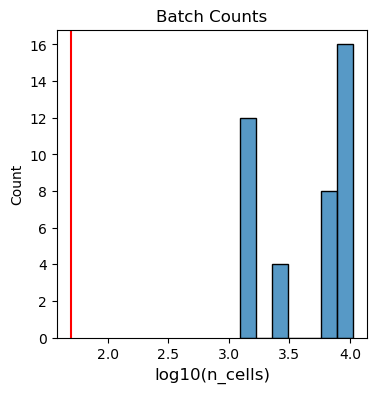

remove 0 batches that have cells less than 50


In [14]:
## Minimum Cell Cutoffs Based on Donor-Batches ##

args_min_n_cells = 50

n_cells_before_qc = notaras_adata.obs.library.value_counts().rename_axis('library').reset_index(name='counts')
n_cells_after_qc = notaras_adata.obs[notaras_adata.obs.passed_qc].library.value_counts().rename_axis('library').reset_index(name='counts')

print('n_cells before QC:', np.sum(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('n_cells after QC:', np.sum(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

print('mean n_cells before QC', np.mean(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('mean n_cells after QC', np.mean(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

# Plot Distribution of Donor-Batches on Being Greater than Zero
plt.figure(figsize=(4, 4))
plt.title('Batch Counts')
sns.histplot(np.log10(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
plt.axvline(np.log10(args_min_n_cells), color='red')
plt.xlabel('log10(n_cells)', fontsize=12)
plt.show()

### n_cells QC

#identify donor-batches with less than 50 cells of contribution
n_cells_outlier = list(n_cells_after_qc[n_cells_after_qc.counts<args_min_n_cells].library)
# set these to have failed QC as well
notaras_adata.obs.loc[notaras_adata.obs.library.isin(n_cells_outlier),'passed_qc'] = False
print('remove {0} batches that have cells less than {1}'.format(len(n_cells_outlier), args_min_n_cells))

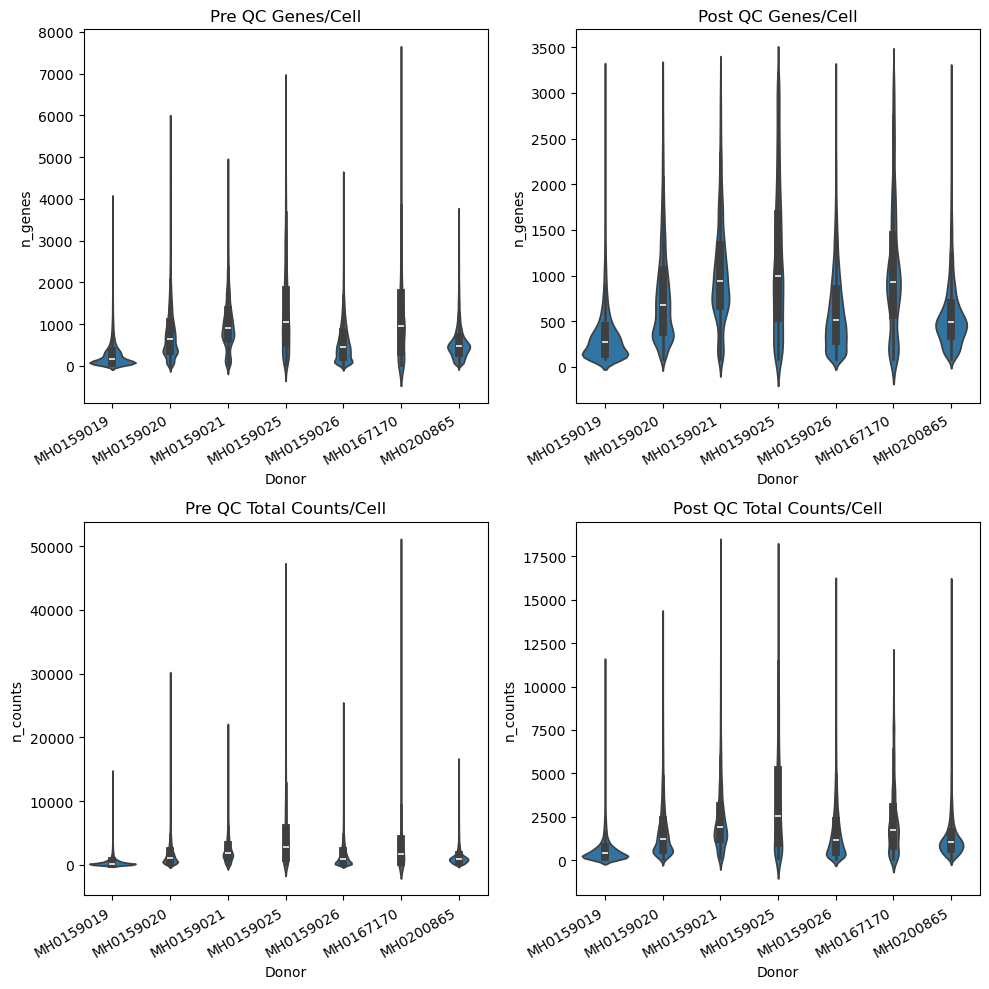

In [15]:
## Trialing QC Cutoffs Before and After ##

## Boolean Cutoffs for UMIs and Genes/Cell ##

counts_filter = (n_counts_lower < notaras_adata.obs.n_genes) & (notaras_adata.obs.n_genes < n_counts_upper)
genes_filter = (n_genes_lower < notaras_adata.obs.n_genes) & (notaras_adata.obs.n_genes < n_genes_upper)

# Plot Changes With Violins 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sns.violinplot(data=notaras_adata.obs, y='n_genes', x='Donor', ax=axes[0])
axes[0].set_title('Pre QC Genes/Cell')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs[counts_filter & genes_filter], x='Donor', y='n_genes', ax=axes[1])
axes[1].set_title('Post QC Genes/Cell')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs, y='n_counts', x='Donor', ax=axes[2])
axes[2].set_title('Pre QC Total Counts/Cell')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=notaras_adata.obs[notaras_adata.obs.passed_qc & genes_filter], x='Donor', y='n_counts', ax=axes[3])
axes[3].set_title('Post QC Total Counts/Cell')
plt.setp(axes[3].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

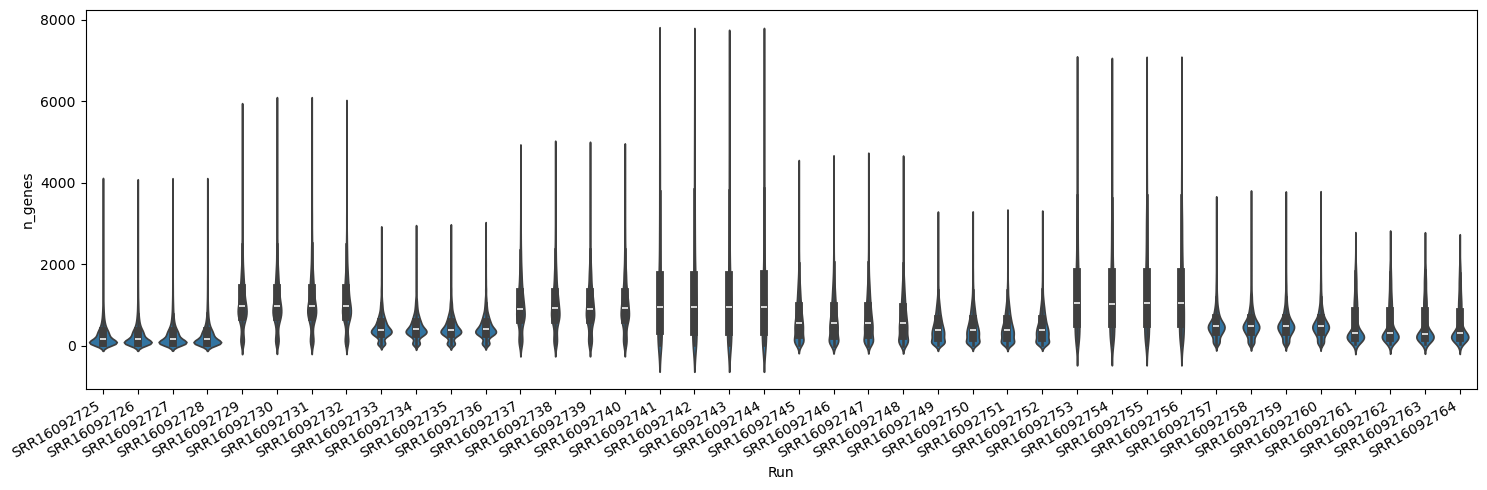

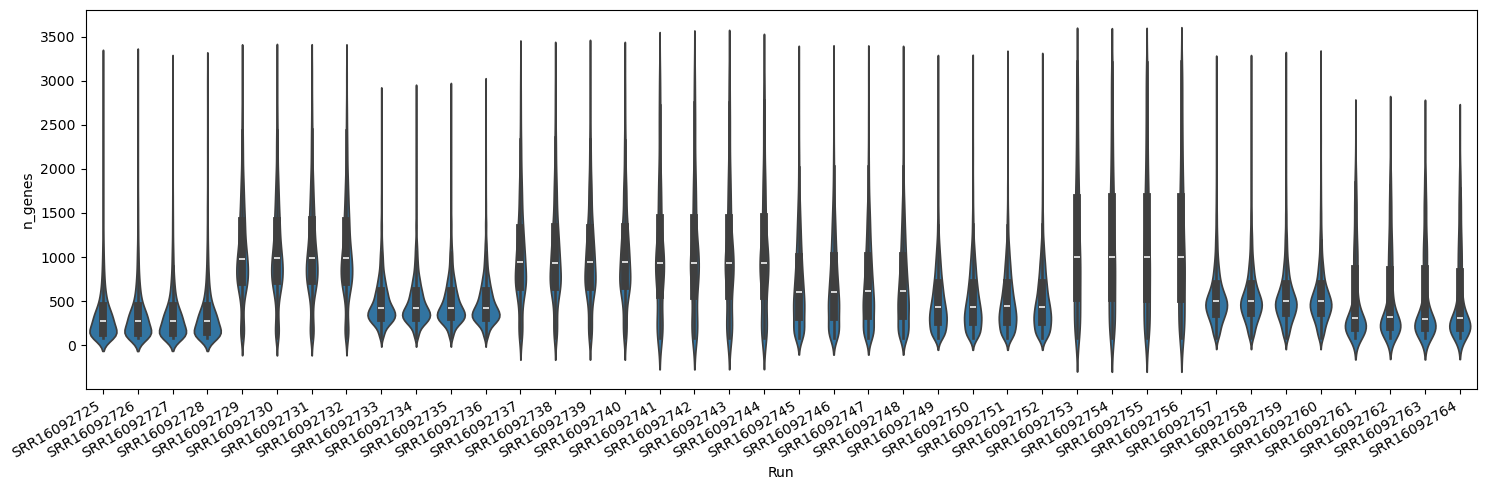

In [16]:
plt.figure(figsize=(15,5))
sns.violinplot(data=notaras_adata.obs, x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.figure(figsize=(15,5))
sns.violinplot(data=notaras_adata.obs[counts_filter & genes_filter], x='Run', y='n_genes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

In [17]:
## Remove Cells That Don't Meet Total Counts/Cell and Genes/Cell Thresholds ##

notaras_adata = MultimodalData(UnimodalData(notaras_adata, modality="rna"))

#notaras_adata = UnimodalData(notaras_adata)
pg.qc_metrics(notaras_adata, 
              min_genes=n_genes_lower, max_genes=n_genes_upper,
              min_umis=n_counts_lower, max_umis=n_counts_upper,
              mito_prefix='MT-', percent_mito=10)

pg.filter_data(notaras_adata)
gc.collect()
notaras_adata = notaras_adata.to_anndata()

2026-02-23 16:33:59,342 - pegasusio.qc_utils - INFO - After filtration, 194257 out of 222930 cell barcodes are kept in UnimodalData object unknown-rna.
2026-02-23 16:33:59,342 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.38s.


In [18]:
## Filter Cells and Genes With Raw Cutoffs #

# store raw counts in layer
notaras_adata.layers["raw_counts"] = notaras_adata.X

# Note: No cells fail this cutoff affter using MAD based filtration
print((notaras_adata.obs.n_genes < 100).sum())
print((notaras_adata.var.n_cells < 20).any())

# Doing This For Completeness
sc.pp.filter_cells(notaras_adata, min_genes=100)
sc.pp.filter_genes(notaras_adata, min_cells=20)

6820
False


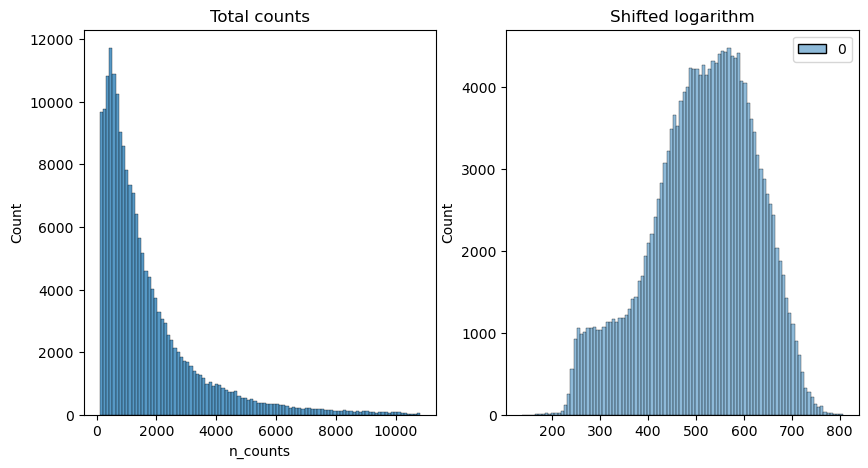

In [19]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(notaras_adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
notaras_adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
notaras_adata.X = notaras_adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(notaras_adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(notaras_adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

2026-02-23 16:34:06,964 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-02-23 16:34:06,967 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-02-23 16:34:07,320 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-02-23 16:34:08,099 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 2.19s.
2026-02-23 16:34:22,014 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 8.83s.


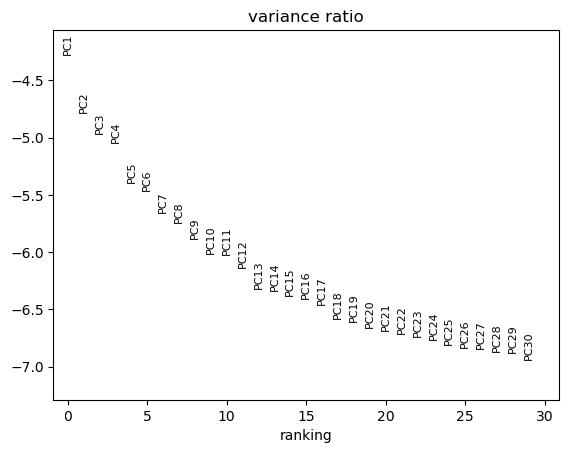

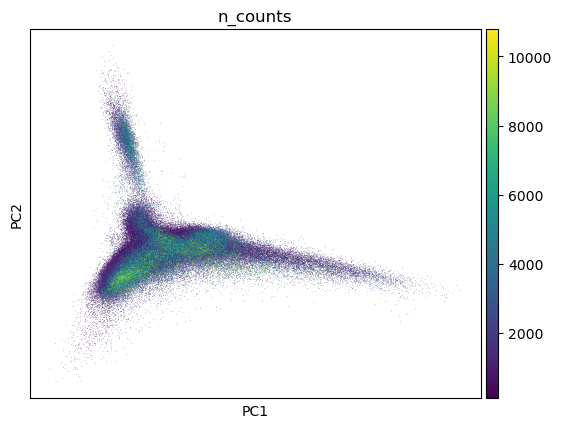

There is 8.44836508521065 variance explained by these components
2026-02-23 16:34:23,039 - pegasus.tools.preprocessing - INFO - Function 'regress_out' finished in 0.37s.
2026-02-23 16:34:23,041 - pegasus.tools.batch_correction - INFO - Start integration using Harmony.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
Reach convergence after 2 iteration(s).
2026-02-23 16:34:59,169 - pegasus.tools.batch_correction - INFO - Function 'run_harmony' finished in 36.13s.
2026-02-23 16:35:45,462 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 46.29s.
2026-02-23 16:35:49,263 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 3.80s.
2026-02-23 16:35:55,421 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 6.16s.
2026-02-23 16:36:49,883 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 5 clusters.
2026-02-23 16:36:50,003 - pegasus.tool

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Feb 23 16:36:51 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Feb 23 16:38:02 2026 Finished embedding
2026-02-23 16:38:02,090 - pegasus.tools.visualization - INFO - Function 'umap' finished in 72.09s.


In [20]:
# Calculate Highly Variable Genes (not using deviance) ##

if not isinstance(notaras_adata, UnimodalData):
    notaras_adata = UnimodalData(notaras_adata)

## ROUND 0 ##

# calc score requires a float downcast for some reason
notaras_adata.X = notaras_adata.X.astype('float32')
pg.calc_signature_score(notaras_adata, 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
notaras_hvg = notaras_adata[:,notaras_adata.var.robust_protein_coding_autosome].copy()
notaras_hvg = notaras_hvg.to_anndata()
hvg = sc.pp.highly_variable_genes(notaras_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False)
hvg_list = notaras_hvg.var.index[hvg.highly_variable].tolist()
del notaras_hvg
gc.collect()

# apply that HVG list to your original anndata object
notaras_adata.var['highly_variable_features'] = False
notaras_adata.var['highly_variable_features'] = notaras_adata.var.index.isin(hvg_list)

## Dimensionality Reduction ##

# PCA

if not isinstance(notaras_adata, UnimodalData):
    notaras_adata = UnimodalData(notaras_adata)

pg.pca(notaras_adata, n_components=30)
sc.pl.pca_variance_ratio(notaras_adata, n_pcs=30, log=True)
sc.pl.pca_scatter(notaras_adata.to_anndata(), color="n_counts")
plt.show()

print('There is {0} variance explained by these components'.format(notaras_adata.uns['pca']['variance_ratio'].sum()*100))

# # Regress Out ##

pg.regress_out(notaras_adata, ['n_counts', 'percent_mito'])

## Harmony  

pg.run_harmony(notaras_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)

# # UMAP

pg.neighbors(notaras_adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(notaras_adata, rep='pca_regressed_harmony', resolution=0.1, class_label='class')
pg.umap(notaras_adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)
plt.show()

notaras_adata = notaras_adata.to_anndata()

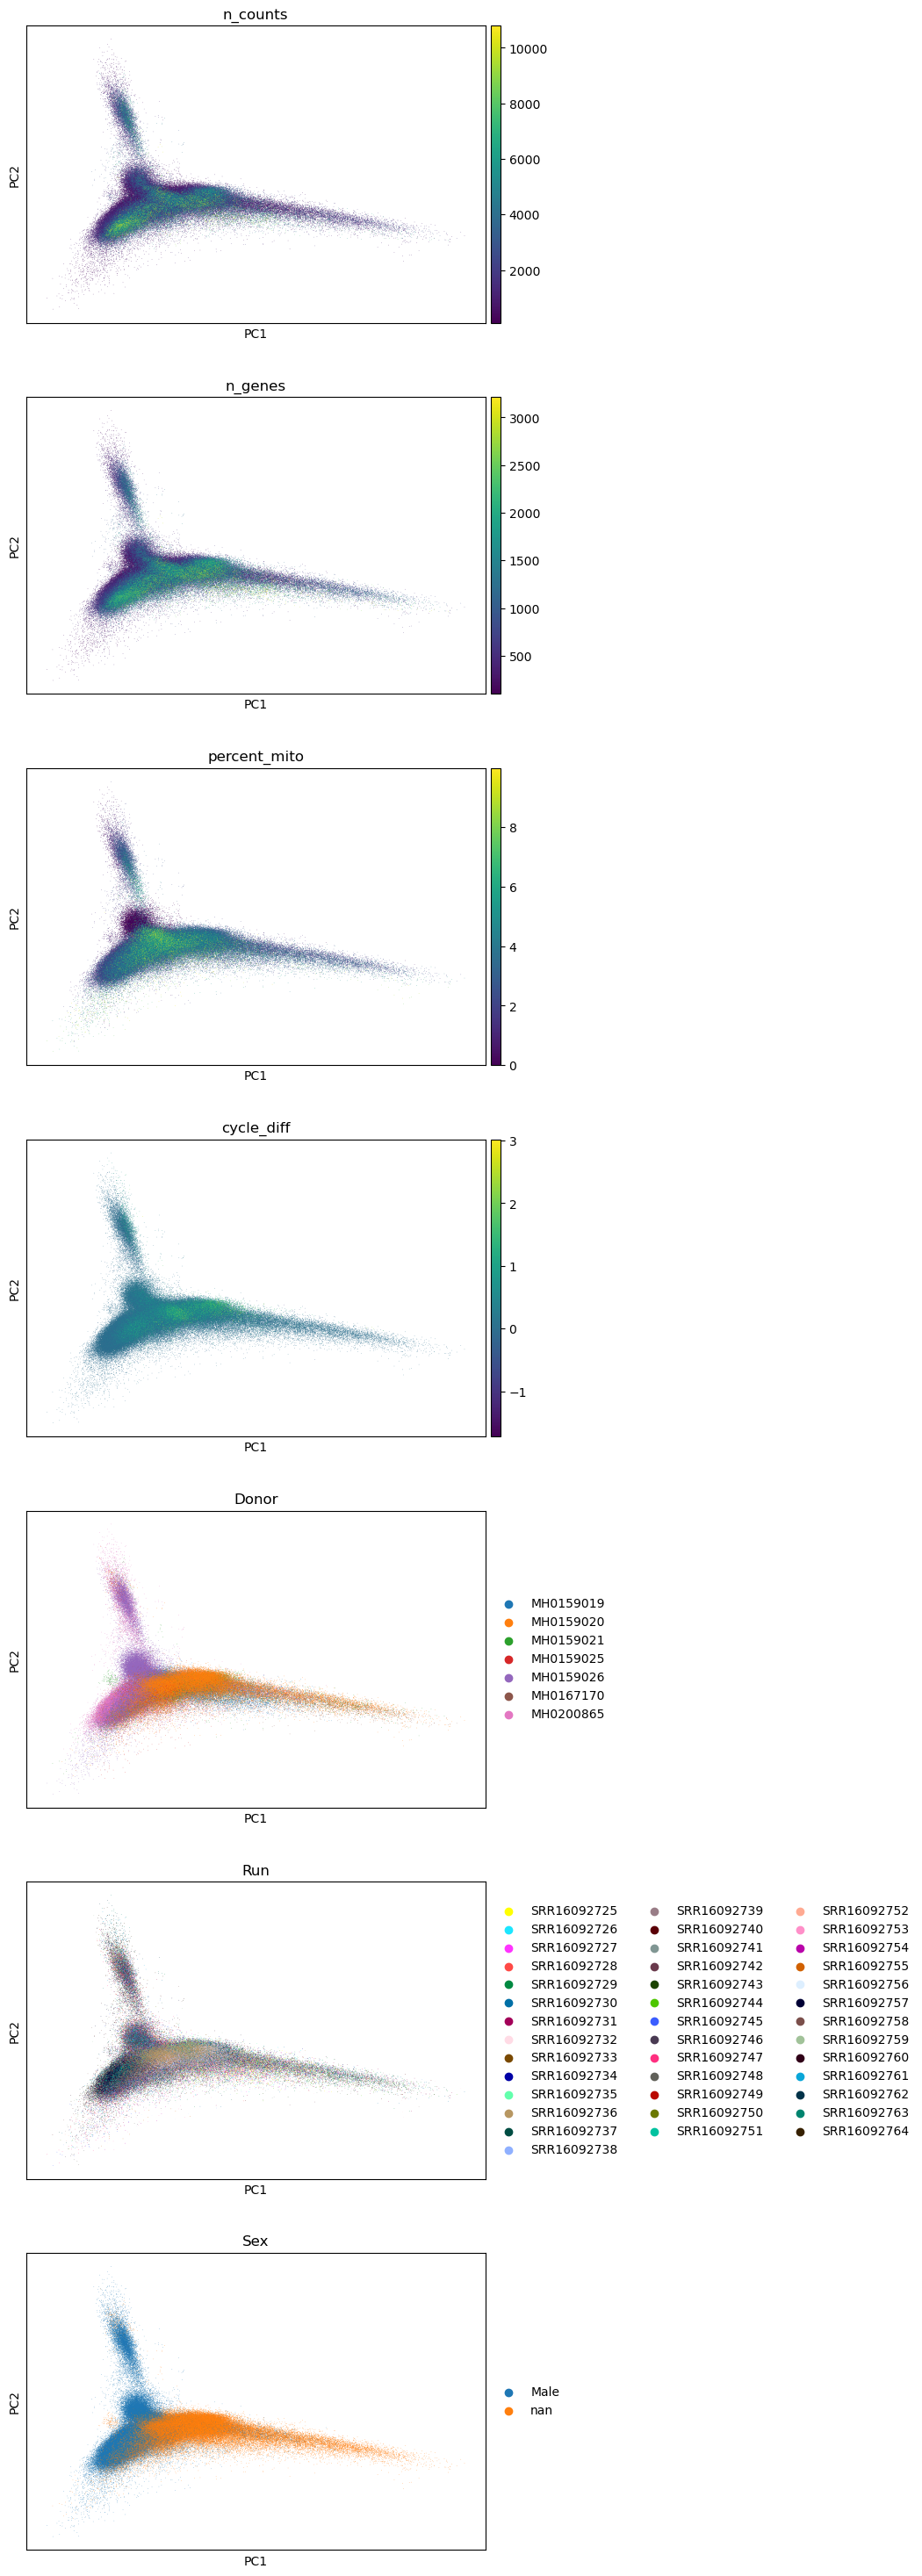

In [21]:
sc.pl.pca(notaras_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

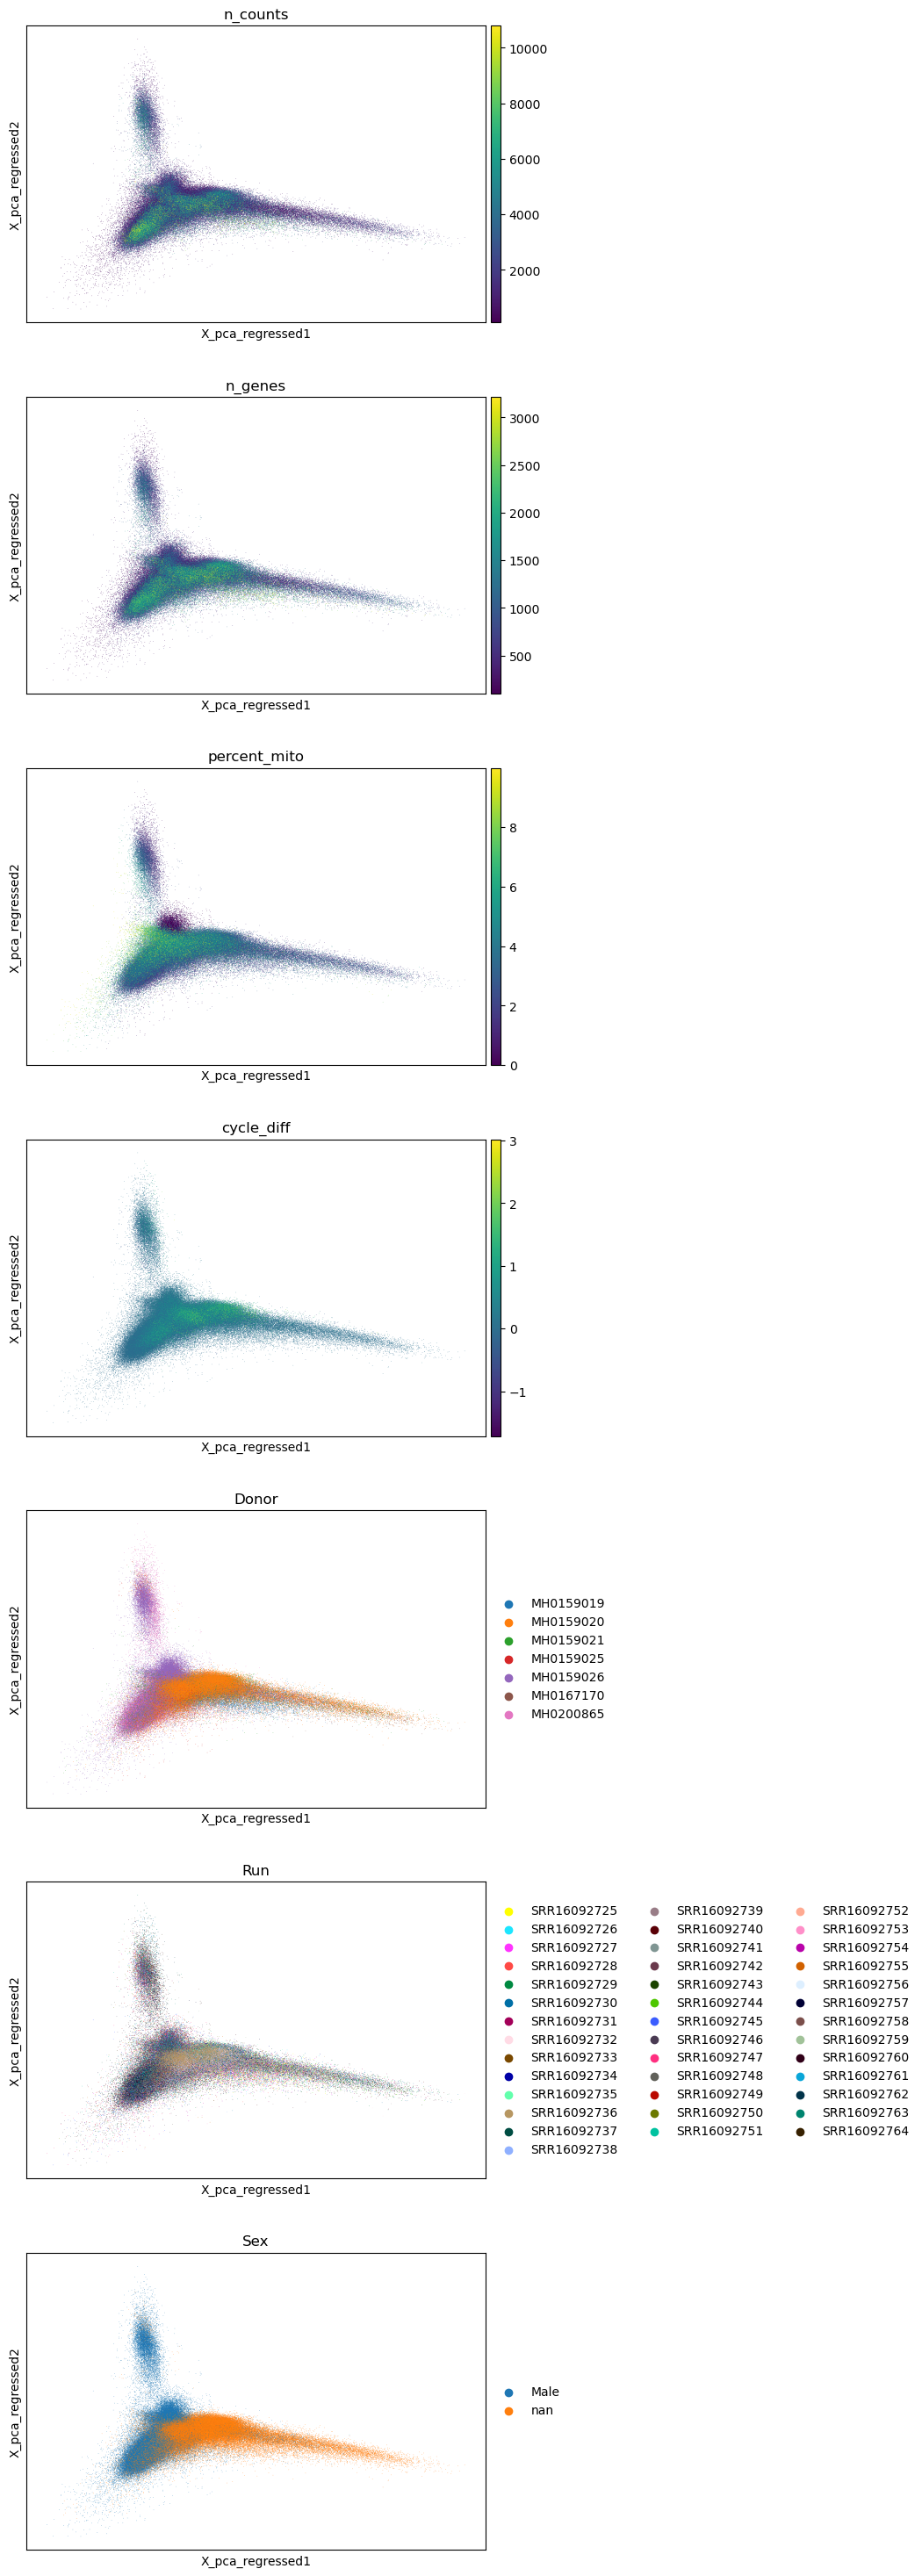

In [22]:
sc.pl.embedding(notaras_adata, basis='X_pca_regressed', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

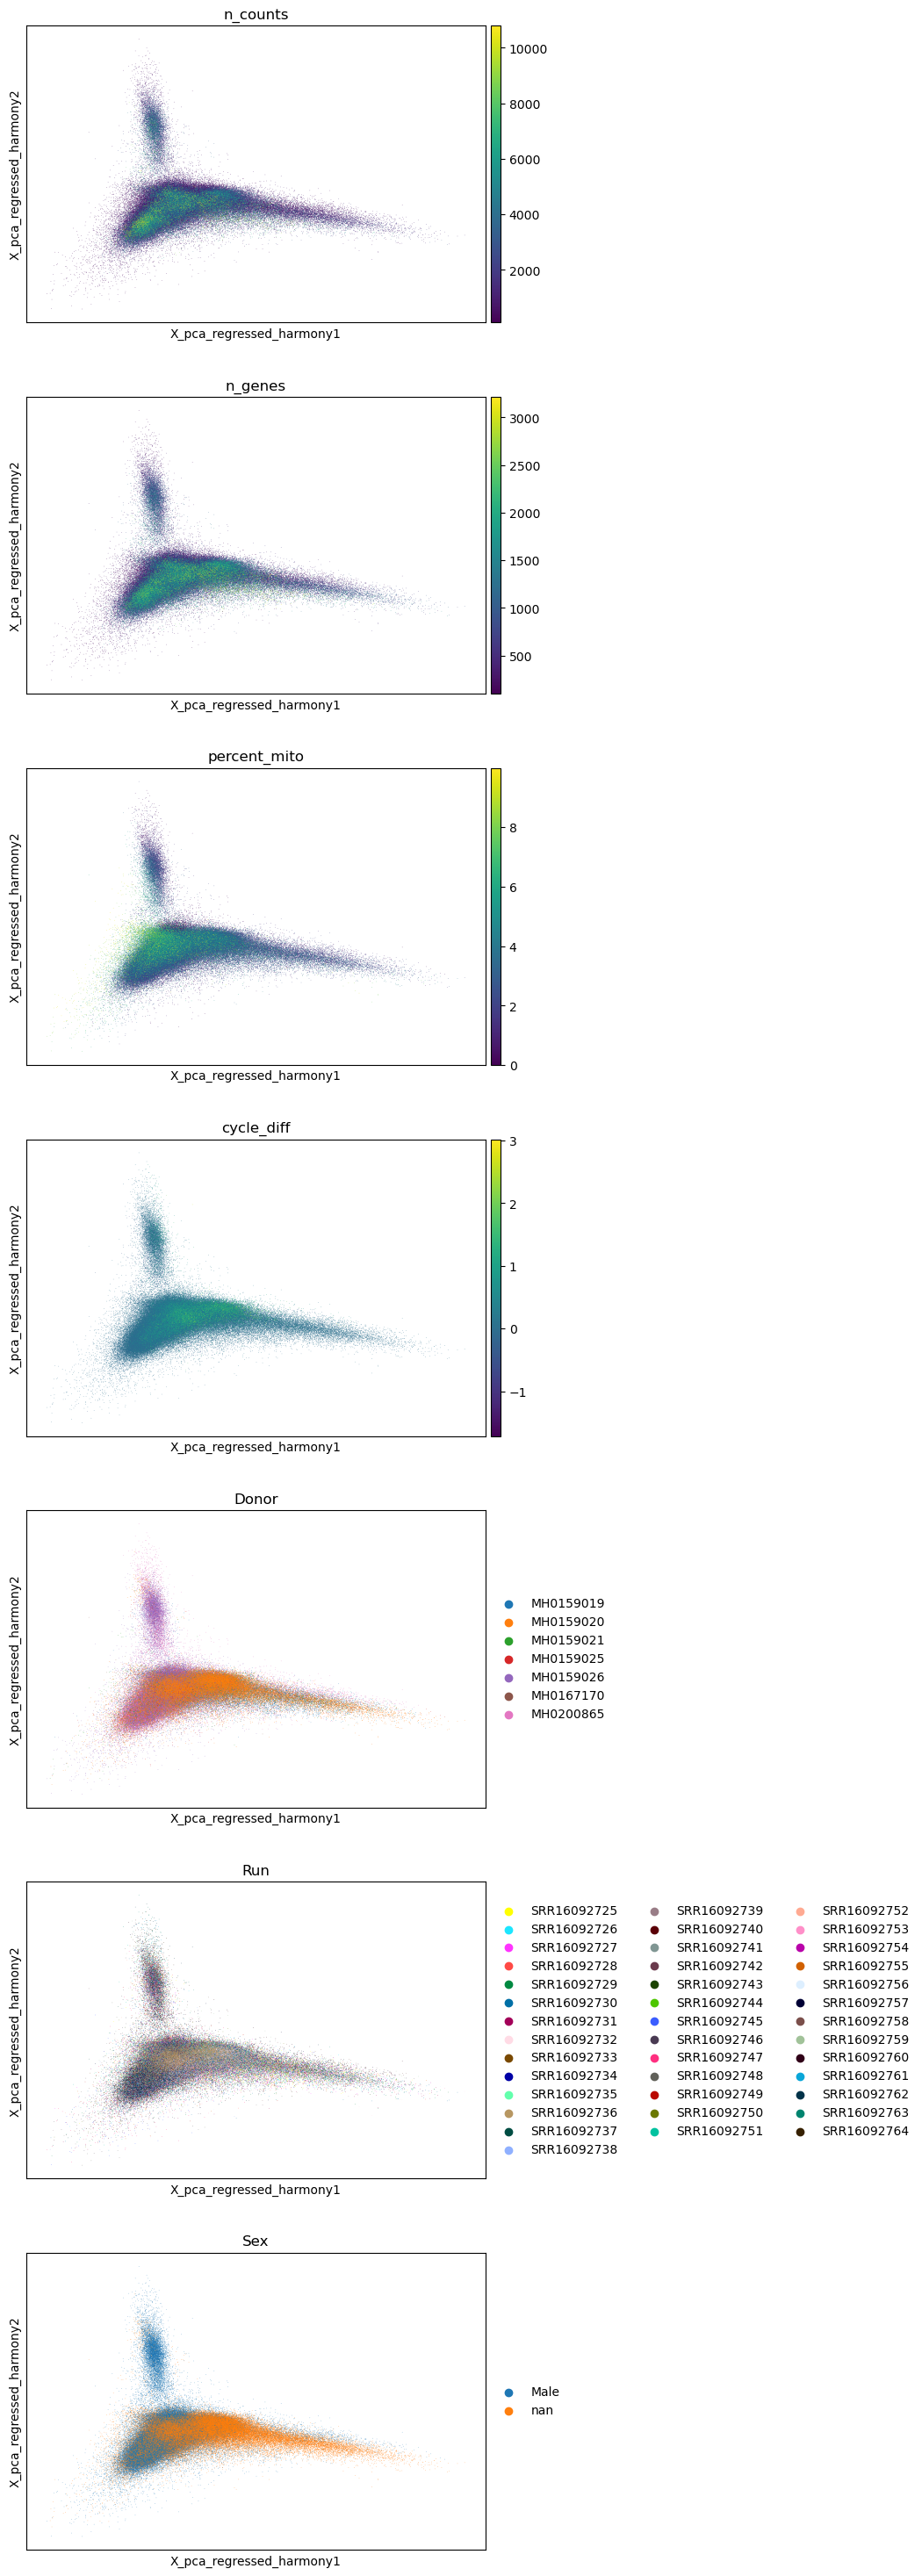

In [23]:
sc.pl.embedding(notaras_adata, basis='X_pca_regressed_harmony', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

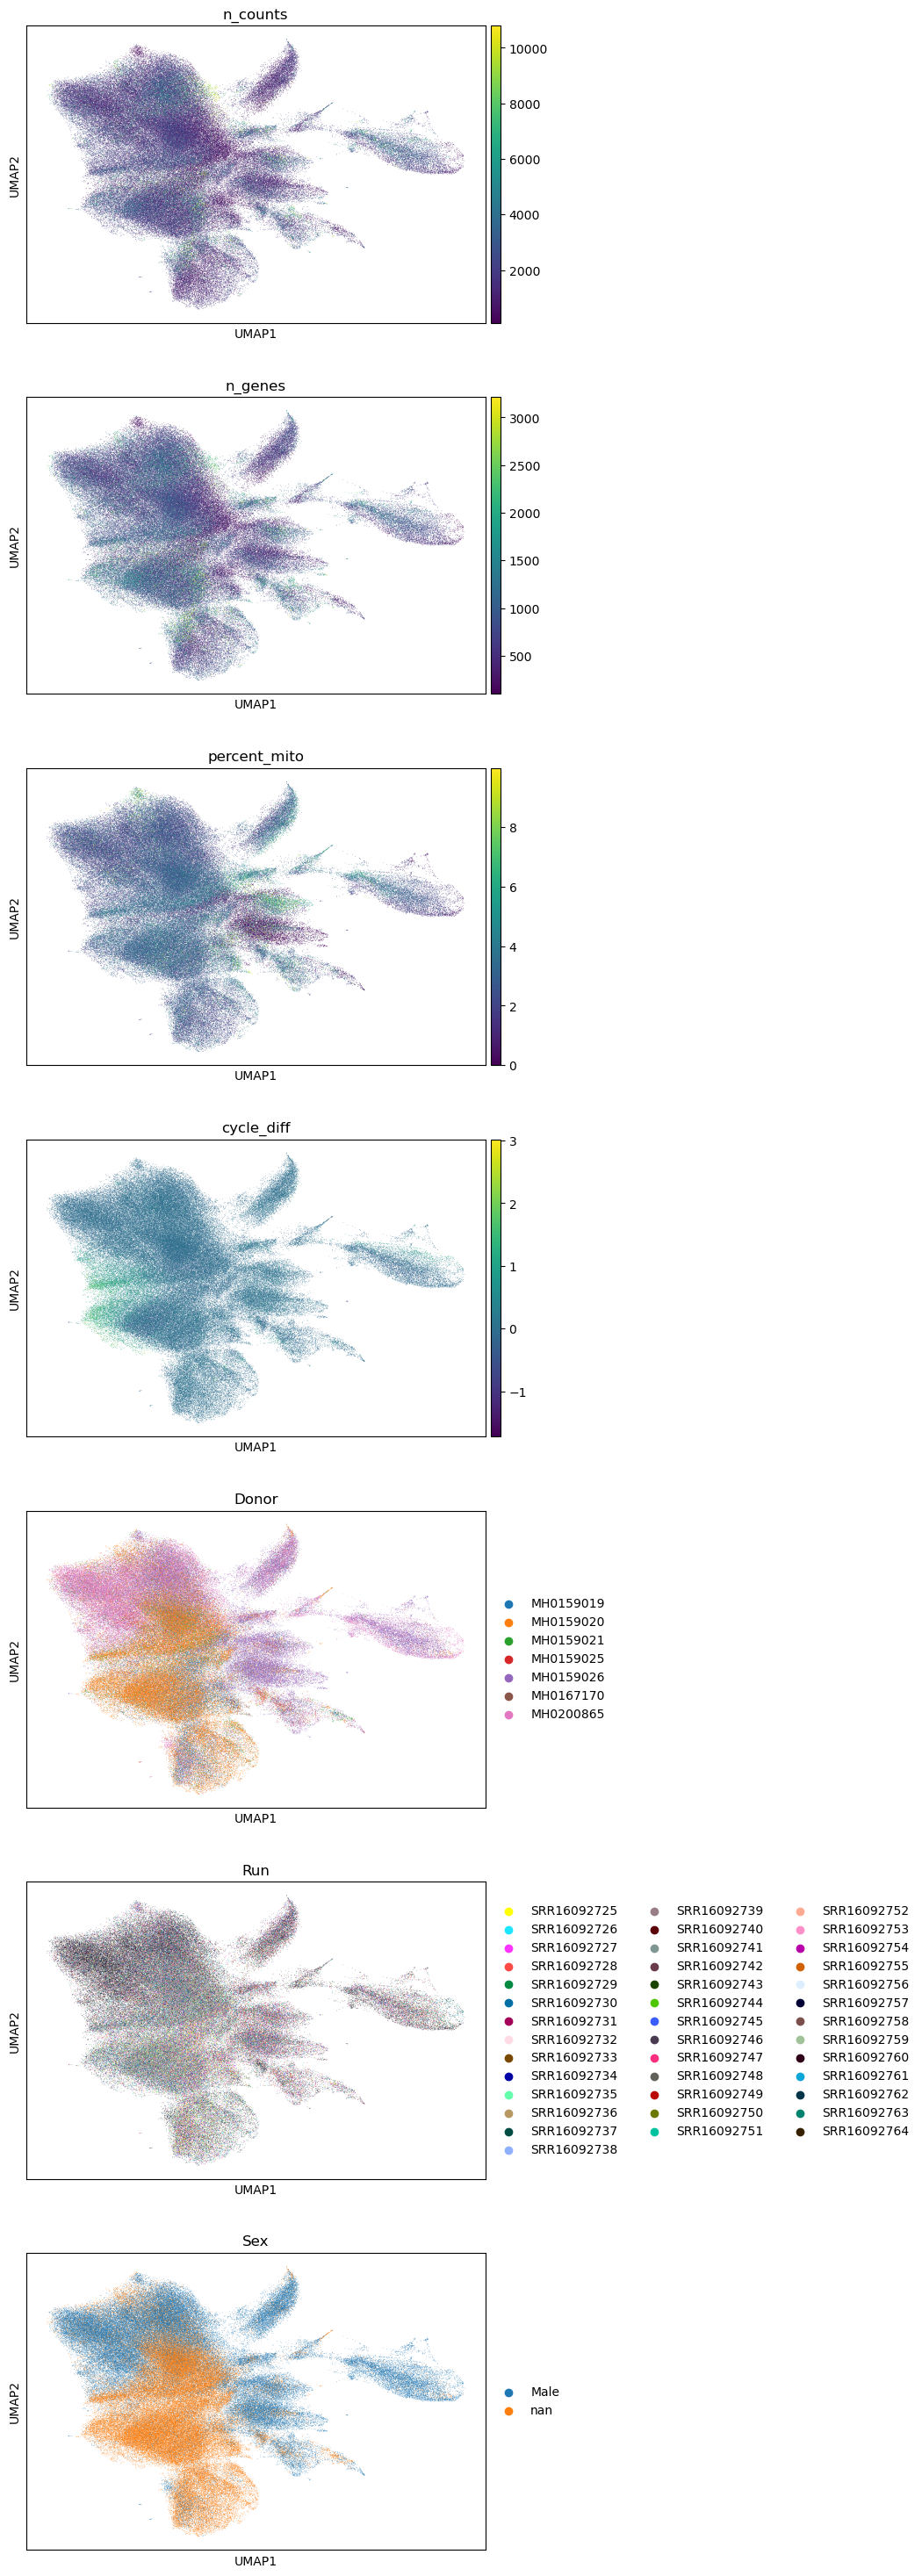

In [24]:
sc.pl.umap(notaras_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Run', 'Sex'], ncols=1)

In [25]:
## Construct Y Chromosomal Expression Matrix For Sex Imputation ##

# Michael Notaras private communication said clinical metadata on healthy lines was not available #

notaras_y_matrix = notaras_adata[:,notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)]].X.toarray()

notaras_y_df = pd.DataFrame(data=notaras_y_matrix, columns=notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)],
          index=notaras_adata.obs_names)

notaras_y_df['Donor'] = notaras_adata[:,notaras_adata.var_names[notaras_adata.var_names.isin(Y_CHR_GENES)]].obs['Donor']

/tmp/ipykernel_129636/1279449471.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(notaras_y_df.groupby('Donor').mean())


<Axes: xlabel='featurekey', ylabel='Donor'>

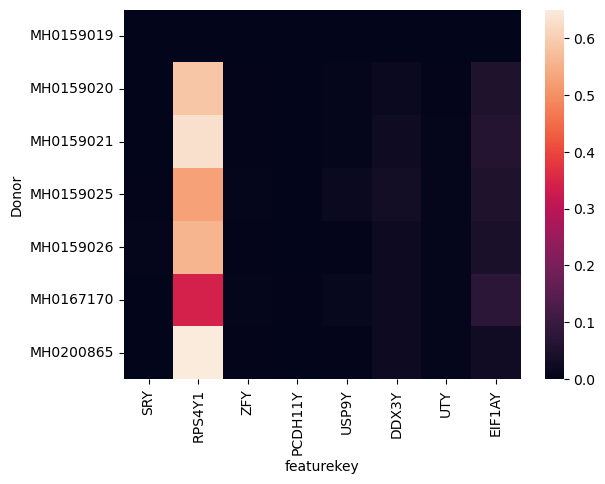

In [26]:
sns.heatmap(notaras_y_df.groupby('Donor').mean())

In [27]:
## Looks as if MH0159020 MH0159021 MH0167170 are likely Male, and MH0159019 female ##

unknown_sex_dict = {'MH0159020': 'Imputed Male', 'MH0159021': 'Imputed Male', 
                    'MH0159019':'Imputed Female', 'MH0167170':'Imputed Male'}

notaras_adata.obs['Imputed_Sex'] = notaras_adata.obs.apply(lambda row: unknown_sex_dict.get(row['Donor'], row['Sex']), axis=1)

notaras_adata.obs['Imputed_Sex'].value_counts()

Imputed_Sex
Male              91326
Imputed Male      74352
Imputed Female    21759
Name: count, dtype: int64

In [28]:
## Align Key Columns Across Datasets ##

notaras_adata.obs['Day'] = '37.5' # Michael Notaras said DIV 35-40
notaras_adata.obs['Genotype'] = notaras_adata.obs['disease_state'].apply(lambda x: 'Control' if x == 'healthy' else 'Idiopathic Schizophrenia')
notaras_adata.obs['Manuscript'] = 'Notaras'
notaras_adata.obs['Protocol'] = 'Lancaster'

In [29]:
## Cells After QC ##

notaras_adata.X.shape

(187437, 16776)

In [30]:
## Save Step ##

notaras_adata.write_h5ad(os.path.join('/mnt/sdb/scz_meta_analysis_processed/notaras_colak/anndata_objs/notaras_qc.h5ad'))